In [18]:
import config as cfg
import numpy as np
import matplotlib.pyplot as plt
from efficiency_finder import get_efficiencies, get_sample_expectations
import os
from glob import glob
import uproot
import awkward as ak
import matplotlib as mpl
from scipy.stats import poisson, norm
from iminuit import Minuit

In [19]:
#Defining key variables
signal_bf=3e-7
MVA1_cut =0.994 # 0.9955
MVA2_cut =0.95 # 0.997
nbins = 5
xrange = (MVA2_cut, 1.00)
bins = np.linspace(xrange[0],xrange[1],nbins+1)


In [20]:
# Getting samples
folder = 'outputs/stage2'
files = {sample: glob(os.path.join(folder, sample, '*.root')) for sample in cfg.samples}

data = {}
for sample in cfg.samples:
    tree = [f'{f}:events' for f in files[sample]]
    data[sample] = uproot.concatenate(tree, expressions='EVT_MVA2', cut='(EVT_MVA1 >= 0.994) & (EVT_MVA2 >= 0.95)')['EVT_MVA2']

In [21]:
# CReating MVA2 cut expressions per bin
cut_expr = []
for i in range(len(bins)):
    if (i+1) == len(bins):
        break
    elif (i+2) == len(bins):
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 <= {bins[i+1]})')
    else:
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 < {bins[i+1]})')

In [22]:
# getting sample expectations and their error
effs = get_efficiencies('stage2', cut=cut_expr, raw=True, verbose=False)
nums = get_sample_expectations(effs, signal_bf, verbose=False, cut=cut_expr)

a=0
#using to calculate total background expectation
B_tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
B_var = np.zeros_like(nums['p8_ee_Zbb_ecm91_err'])

for sample in cfg.samples:
    if sample in cfg.sample_allocations['background']:
        if a==0:
            B_tot = B_tot + nums[sample+'_num']
            B_var = B_var + nums[sample+'_err']**2
            B = nums[sample+'_num']
            B_err = nums[sample+'_err']
        else:
            B_tot = B_tot + nums[sample+'_num']
            B_var = B_var + nums[sample+'_err']**2
            B_err = np.vstack((B_err,nums[sample+'_err']))
            B = np.vstack((B,nums[sample+'_num']))
        a+=1

sig_B = np.sqrt(B_var)
bkg_labels=cfg.sample_allocations['background']
n_bkgs=len(bkg_labels)

In [23]:
print(B)

[[ 256343.17229397  343169.08549032  467206.10434224  797971.48794737
  1170082.54450313]
 [ 236773.97795272  297411.21620891  407135.74257725  505310.31880155
   490872.8811215 ]
 [ 657848.71692089  756716.154146    977266.59103277 1232040.37157438
   965858.80981449]
 [ 117201.52750584  182313.48723131  240914.25098423  273470.23084697
   130223.91945094]]


In [24]:
#Check summation working as expect - these should be equal
print( np.sum(B, axis=0) )
print(B_tot)

[1268167.39467343 1579609.94307654 2092522.68893649 2808792.40917027
 2757038.15489006]
[1268167.39467343 1579609.94307654 2092522.68893649 2808792.40917027
 2757038.15489006]


In [25]:
#defining coloiur scheme and binning
reds = mpl.colormaps['Reds_r']
cols = reds(np.linspace(0, 1, 8)[2:-2])
bin_centres = (bins[:-1]+bins[1:])/2

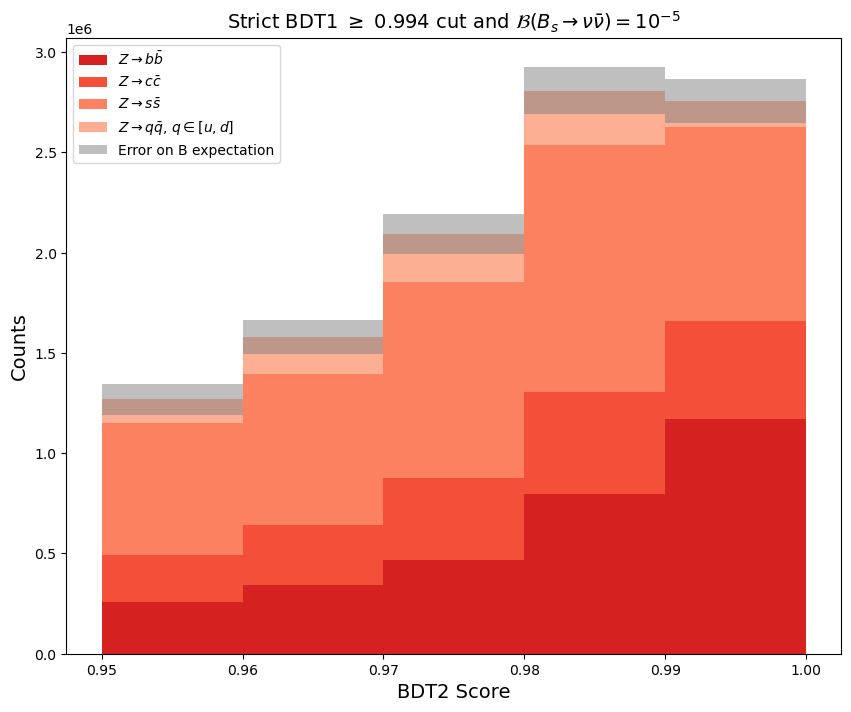

In [26]:
#plottoing
fig, ax = plt.subplots(figsize=(10,8))
B_running_tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
for i in range(n_bkgs):
    ax.bar(bin_centres, B[i], width=np.diff(bins), align='center', color=cols[i], label=cfg.titles[f'{bkg_labels[i]}'], bottom=B_running_tot)
    B_running_tot += B[i]

ax.bar(bin_centres, 2*sig_B, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=B_tot-sig_B, label='Error on B expectation') #from error in efficiency
#ax.errorbar(bin_centres, B_tot, xerr=0.5*np.diff(bins), yerr=sig_B, fmt='None', ecolor='black', elinewidth=1, capsize=2)

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
plt.show()

In [27]:
# Now define signal
S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num']
sig_S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err']


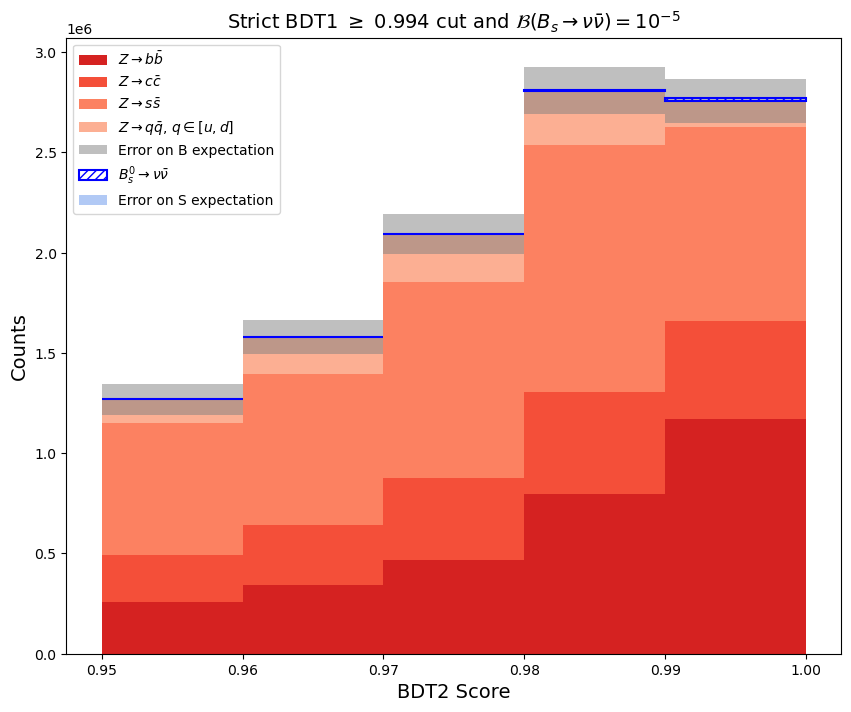

In [28]:
#plottoing
fig, ax = plt.subplots(figsize=(10,8))
B_running_tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
for i in range(n_bkgs):
    ax.bar(bin_centres, B[i], width=np.diff(bins), align='center', color=cols[i], label=cfg.titles[f'{bkg_labels[i]}'], bottom=B_running_tot)
    B_running_tot += B[i]

ax.bar(bin_centres, 2*sig_B, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=B_tot-sig_B, label='Error on B expectation') #from error in efficiency
#ax.errorbar(bin_centres, B_tot, xerr=0.5*np.diff(bins), yerr=sig_B, fmt='None', ecolor='black', elinewidth=1, capsize=2)

ax.bar(bin_centres, S, width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],
       bottom=B_tot)
#ax.errorbar(bin_centres,B_tot+S, xerr=0.5*np.diff(bins), yerr=sig_S, fmt='None', ecolor='Blue', elinewidth=1, label='S expectation', capsize=2)
ax.bar(bin_centres, 2*sig_S, width=np.diff(bins), align='center', color='cornflowerblue', alpha=0.5, bottom=B_tot+S-sig_S, label='Error on S expectation') #from error in efficiency

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$', fontsize=14)
ax.legend(loc='best')
plt.show()

In [29]:
poisson_expectation = B_tot + S

In [30]:
print(B_tot)

[1268167.39467343 1579609.94307654 2092522.68893649 2808792.40917027
 2757038.15489006]


In [31]:
# throw toy
toy_data = np.random.poisson(poisson_expectation)

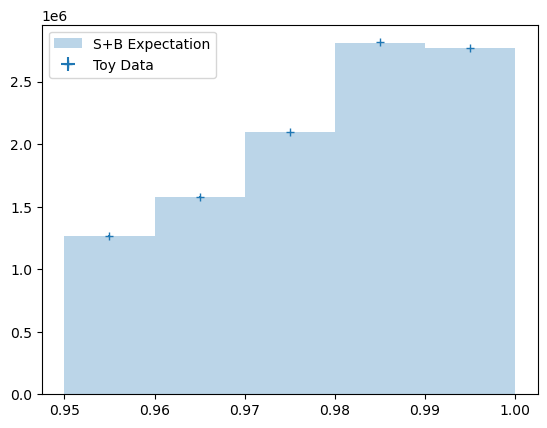

In [32]:
fig, ax = plt.subplots()
ax.bar( bin_centres, poisson_expectation, width=np.diff(bins), alpha=0.3, label='S+B Expectation')
ax.errorbar( bin_centres, toy_data, xerr=0, yerr=toy_data**0.5,fmt='+', label='Toy Data') # poisson error on toy data
ax.legend()

In [33]:
average_background_error = np.mean( sig_B / B_tot )
print( average_background_error )


0.04882027819581778


In [34]:
## fit the toy (this is the negative log likelihood that I want to minimize)
def poisson_likelihood(sc_b, sc_s):
    expectation = sc_b * B_tot + sc_s * S
    poiss_term = -np.sum( poisson.logpmf(toy_data, expectation)) #logpmf = Log of the probability mass function
    #print(poisson.logpmf(toy_data, expectation))
    #print(np.sum(poisson.logpmf(toy_data, expectation)))
    bkg_constraint_term = -norm.logpdf( sc_b, 1, average_background_error )
    return poiss_term + bkg_constraint_term


def plot(sc_b, sc_s):
    bkg = sc_b * B_tot 
    sig = sc_s * S
    
    fig, ax = plt.subplots()
    ax.errorbar( bin_centres, toy_data, yerr=toy_data**0.5, fmt='+' ,label='Toy data')
    ax.bar( bin_centres, bkg, width=np.diff(bins), alpha=0.4 ,color='r',label=r'$N_B$ fit value')
    ax.bar( bin_centres, sig, width=np.diff(bins), bottom=bkg, alpha=0.4,color='cornflowerblue',label=r'$N_S$ fit value')
    ax.legend()

In [35]:
# throw toy
toy_data = np.random.poisson(poisson_expectation)

In [36]:
from iminuit import Minuit

mi = Minuit(poisson_likelihood, sc_b=1, sc_s=1 )
#mi.fixed['sc_b'] = True
mi.migrad()
mi.hesse()
print(mi)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 39.75                      │              Nfcn = 45               │
│ EDM = 5.4e-08 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

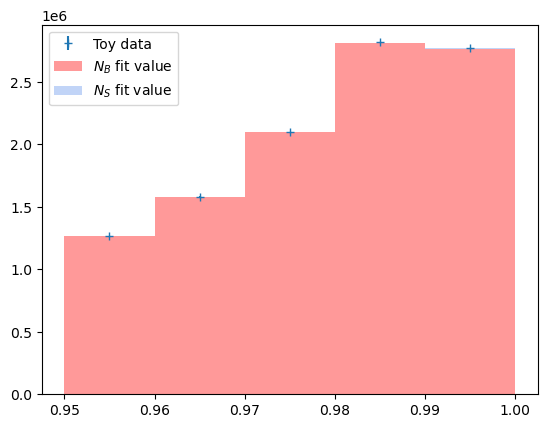

In [37]:
plot( mi.values['sc_b'], mi.values['sc_s'] )

In [38]:
# To see fit apply flattenig transform and plot small window
def plot_flattened(sc_b, sc_s):
    bkg_flat = sc_b * B_tot / np.sum(B, axis=0) * np.sum(np.sum(B, axis=0),axis=0)/5
    sig_flat = sc_s * S / np.sum(B, axis=0) * np.sum(np.sum(B, axis=0),axis=0)/5
    
    fig, ax = plt.subplots()
    ax.errorbar( bin_centres, toy_data/np.sum(B, axis=0) * np.sum(np.sum(B, axis=0),axis=0)/5, yerr=toy_data**0.5, fmt='None' ,label='Toy data',capsize=2)
    ax.bar( bin_centres, bkg_flat, width=np.diff(bins), alpha=0.4 ,color='r',label=r'$N_B$ fit value')
    ax.bar( bin_centres, sig_flat, width=np.diff(bins), bottom=bkg_flat, alpha=0.4,color='cornflowerblue',label=r'$N_S$ fit value')
    ax.legend()
    ax.set_ylim(2.08e6,2.18e6)

    

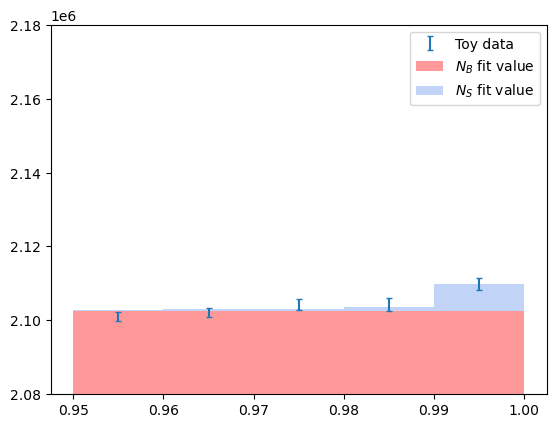

In [39]:
plot_flattened( mi.values['sc_b'], mi.values['sc_s'] )


In [40]:

# refit with S=0 fixed for significance
mi0 = Minuit(poisson_likelihood, sc_b=1, sc_s=0 )
mi0.fixed['sc_s'] = True
mi0.migrad()
mi0.hesse()
print(mi0)


significance = np.sqrt(abs(2*(mi.fval-mi0.fval)))
print(significance)

'''
I'm not sure if this significance makes sense here - ie. fitting a distirbution of toys back to what it was generated from then comparing to null hypothesis - i guess it does in a how much you could tell it from the null hypothesis perspective
'''

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 50.09                      │              Nfcn = 18               │
│ EDM = 5.72e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

"\nI'm not sure if this significance makes sense here - ie. fitting a distirbution of toys back to what it was generated from then comparing to null hypothesis - i guess it does in a how much you could tell it from the null hypothesis perspective\n"

### Example for plot significance against bf

In [19]:
#Defining key variables
signal_bf_list=[3e-7,1e-6,1e-5,1e-4]
av_significance_for_bf = []
stdev_significance_for_bf=[]

MVA1_cut = 0.994
MVA2_cut = 0.95
nbins = 5
xrange = (MVA2_cut, 1.00)
bins = np.linspace(xrange[0],xrange[1],nbins+1)
ntoys = 250

#defining coloiur scheme and binning
reds = mpl.colormaps['Reds_r']
cols = reds(np.linspace(0, 1, 8)[2:-2])
bin_centres = (bins[:-1]+bins[1:])/2

# Getting samples
folder = 'outputs/stage2'
files = {sample: glob(os.path.join(folder, sample, '*.root')) for sample in cfg.samples}


data = {}
for sample in cfg.samples:
    tree = [f'{f}:events' for f in files[sample]]
        data[sample] = uproot.concatenate(tree, expressions='EVT_MVA2', cut=f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {MVA2_cut})')['EVT_MVA2']

# CReating MVA2 cut expressions per bin
cut_expr = []
for i in range(len(bins)):
    if (i+1) == len(bins):
        break
    elif (i+2) == len(bins):
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 <= {bins[i+1]})')
    else:
        cut_expr.append(f'(EVT_MVA1 >= {MVA1_cut}) & (EVT_MVA2 >= {bins[i]}) & (EVT_MVA2 < {bins[i+1]})')

for bf in signal_bf_list:
    # getting sample expectations and their error
    effs = get_efficiencies('stage2', cut=cut_expr, raw=True, verbose=False)
    nums = get_sample_expectations(effs, bf, verbose=False, cut=cut_expr)
    
    a=0
    #using to calculate total background expectation
    B_tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
    B_var = np.zeros_like(nums['p8_ee_Zbb_ecm91_err'])
    
    for sample in cfg.samples:
        if sample in cfg.sample_allocations['background']:
            if a==0:
                B_tot = B_tot + nums[sample+'_num']
                B_var = B_var + nums[sample+'_err']**2
                B = nums[sample+'_num']
                B_err = nums[sample+'_err']
            else:
                B_tot = B_tot + nums[sample+'_num']
                B_var = B_var + nums[sample+'_err']**2
                B_err = np.vstack((B_err,nums[sample+'_err']))
                B = np.vstack((B,nums[sample+'_num']))
            a+=1
    #defining bkg errors
    sig_B = np.sqrt(B_var)
    average_background_error = np.mean( sig_B / B_tot )
    #defining bkg labels
    bkg_labels=cfg.sample_allocations['background']
    n_bkgs=len(bkg_labels)
    

    # Now define signal and poisson expectation
    S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_num']
    sig_S = nums['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_err']
    poisson_expectation = B_tot + S
    
    
    ## define fit to toy (this is the negative log likelihood to minimize)
    def poisson_likelihood(sc_b, sc_s):
        expectation = sc_b * B_tot + sc_s * S
        poiss_term = -np.sum( poisson.logpmf(toy_data, expectation)) #logpmf = Log of the probability mass function
        bkg_constraint_term = -norm.logpdf( sc_b, 1, average_background_error )
        return poiss_term + bkg_constraint_term
    
    sc_s_arr=[]
    sc_s_err_arr=[]
    sc_b_arr=[]
    sc_b_err_arr=[]
    fval_arr=[]
    mi_arr=[]
    significance_arr=[]
    
    # throw and refit toys
    for n in range(ntoys):
        toy_data = np.random.poisson(poisson_expectation) #throw toys
        mi = Minuit(poisson_likelihood, sc_b=1, sc_s=1 ) #fit toy
        mi.migrad()
        mi.hesse()
        sc_s_arr.append(mi.values['sc_s'])
        sc_b_arr.append(mi.values['sc_b'])
        sc_s_err_arr.append(mi.errors['sc_s'])
        sc_b_err_arr.append(mi.errors['sc_b'])
        fval_arr.append(mi.fval)
        mi_arr.append(mi)
        
        # refit with S=0 fixed for significance
        mi0 = Minuit(poisson_likelihood, sc_b=1, sc_s=0 )
        mi0.fixed['sc_s'] = True
        mi0.migrad()
        mi0.hesse()
        #print(mi0)

        significance = np.sqrt(abs(2*(mi.fval-mi0.fval)))
        significance_arr.append(significance)


    sc_b_av = np.average(sc_b_arr)
    sc_s_av = np.average(sc_s_arr)
    sc_b_err_av = np.average(sc_b_err_arr)
    sc_s_err_av = np.average(sc_s_err_arr)
    
    sc_s_stdev = np.std(sc_s_arr) #if take enough toys expect to match sc_s_err_av
    sc_b_stdev = np.std(sc_b_arr) #if take enough toys expect to match sc_b_err_av
    
    significance_av = np.average(significance_arr)
    significance_stdev = np.std(significance_arr)
    av_significance_for_bf.append(significance_av)
    stdev_significance_for_bf.append(significance_stdev)


In [20]:
av_significance_for_bf

[5.783260230148449, 19.29028364333226, 186.36359132390052, 1499.0403464426984]

In [21]:
stdev_significance_for_bf

[1.0236279713232912,
 0.9410129776450288,
 0.9972565849102819,
 1.0635602228913417]

### Without gaussian contrsiant for comparison

In [25]:
def poisson_likelihood_no_constraint(sc_b, sc_s):
    expectation = sc_b * B_tot + sc_s * S
    poiss_term = -np.sum( poisson.logpmf(toy_data, expectation)) #logpmf = Log of the probability mass function
    return poiss_term 

In [26]:
# Fixing bkg for comparison:

mi2 = Minuit(poisson_likelihood_no_constraint, sc_b=1, sc_s=1 )
mi2.fixed['sc_b'] = True
mi2.migrad()
mi2.hesse()
print(mi2)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 43.54                      │              Nfcn = 24               │
│ EDM = 1.41e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

In [27]:
# Completely free bkg for comparison:

mi3 = Minuit(poisson_likelihood_no_constraint, sc_b=1, sc_s=1 )
mi3.migrad()
mi3.hesse()
print(mi3)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 43.28                      │              Nfcn = 47               │
│ EDM = 4.76e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

## Flattening bkg distribution

In [24]:
# \Flatten total bkg distribution
B_norm = B / np.sum(B, axis=0)#.reshape(-1,1)
print(B_norm)

[[0.2021367  0.21724926 0.22327409 0.28409771 0.42439839]
 [0.18670562 0.18828143 0.19456694 0.17990305 0.17804356]
 [0.51873966 0.47905254 0.46702795 0.43863703 0.35032479]
 [0.09241803 0.11541678 0.11513101 0.09736221 0.04723327]]


In [25]:
#check normalisation worked as expected
np.sum( B_norm, axis=0)

array([1., 1., 1., 1., 1.])

In [26]:
#creating flattened bkg with correct count
B_flat = B_norm* np.sum(np.sum(B, axis=0),axis=0)/5

In [27]:
print(B_flat)
#check done flattening correctly
print(np.sum(np.sum( B_flat, axis=0),axis=0))
print(np.sum(np.sum(B, axis=0),axis=0))

[[ 424734.91362082  456489.81163621  469149.35460111  596953.52584238
   891756.97425148]
 [ 392310.72227693  395621.85466596  408829.14219211  378016.98558059
   374109.77308178]
 [1089989.31181413 1006597.70729239  981331.33577466  921675.59229886
   736111.59643446]
 [ 194191.17043748  242516.7445548   241916.28558147  204580.01442753
    99247.77438163]]
10506130.590746785
10506130.590746783


In [28]:
#Applying transform to signal
S_flat = S/np.sum(B, axis=0) * np.sum(np.sum(B, axis=0),axis=0)/5

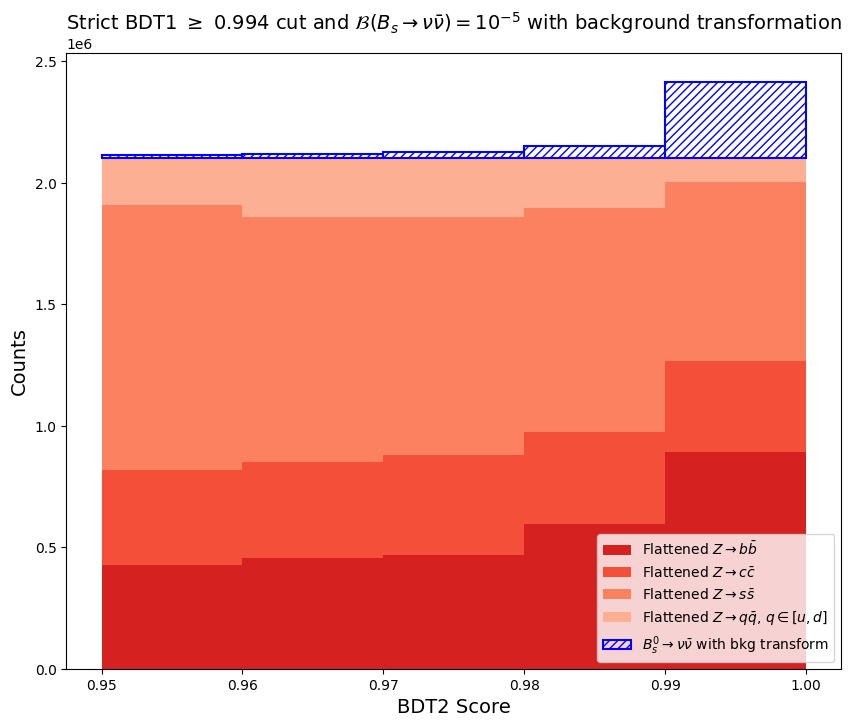

In [31]:
# with bkg flattened
fig, ax = plt.subplots(figsize=(10,8))
B_running_tot = np.zeros_like(nums['p8_ee_Zbb_ecm91_num'])
for i in range(n_bkgs):
    ax.bar(bin_centres, B_flat[i], width=np.diff(bins), align='center', color=cols[i], label='Flattened '+ cfg.titles[f'{bkg_labels[i]}'], bottom=B_running_tot)
    B_running_tot += B_flat[i]

#ax.bar(bin_centres, 2*sig_B, width=np.diff(bins), align='center', color='gray', alpha=0.5, bottom=B_tot-sig_B, label='Error on B expectation') #from error in efficiency
#ax.errorbar(bin_centres, B_tot, xerr=0.5*np.diff(bins), yerr=sig_B, fmt='None', ecolor='black', elinewidth=1, capsize=2)

ax.bar(bin_centres, S_flat, width=np.diff(bins), align='center', 
       edgecolor='blue', hatch='////', facecolor='none', 
       linewidth=1.5, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'] +' with bkg transform',
       bottom=B_running_tot)
#ax.errorbar(bin_centres,B_tot+S, xerr=0.5*np.diff(bins), yerr=sig_S, fmt='None', ecolor='Blue', elinewidth=1, label='S expectation', capsize=2)
#ax.bar(bin_centres, 2*sig_S, width=np.diff(bins), align='center', color='cornflowerblue', alpha=0.5, bottom=B_tot+S-sig_S, label='Error on S expectation') #from error in efficiency

ax.set_xlabel('BDT2 Score', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.set_title(r'Strict BDT1 $\geq$ 0.994 cut and $\mathcal{B}(B_s\to\nu\bar{\nu}) = 10^{-5}$ with background transformation', fontsize=14)
ax.legend(loc='best')
plt.show()